In [9]:
import os
import sys
import json
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.gridspec  as gridspec
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [10]:
# ─── Verify all required files exist before loading anything ─────────────────
# If any file is missing, this cell stops execution with a clear message.

REQUIRED_FILES = {
    "Trained Model"    : "../models/best_model.pkl",
    "X_test"           : "../data/processed/X_test.csv",
    "y_test"           : "../data/processed/y_test.csv",
    "Feature Names"    : "../data/processed/feature_names.csv",
    "Cleaned Dataset"  : "../data/processed/cleaned_data.csv",
}

missing = {k: v for k, v in REQUIRED_FILES.items() if not os.path.exists(v)}

if missing:
    print("❌ Missing files — run previous notebooks first:\n")
    for name, path in missing.items():
        print(f"   [{name}]  →  {path}")
    print("\n   Run order: 02_preprocessing.ipynb → 03_model_building.ipynb → this notebook")
    raise FileNotFoundError("Required files missing. See above.")

print("✅ All required files found:\n")
for name, path in REQUIRED_FILES.items():
    size_kb = os.path.getsize(path) / 1024
    print(f"   ✅  {name:20s}  →  {path}  ({size_kb:.1f} KB)")

✅ All required files found:

   ✅  Trained Model         →  ../models/best_model.pkl  (43986.6 KB)
   ✅  X_test                →  ../data/processed/X_test.csv  (1072.7 KB)
   ✅  y_test                →  ../data/processed/y_test.csv  (4.1 KB)
   ✅  Feature Names         →  ../data/processed/feature_names.csv  (0.9 KB)
   ✅  Cleaned Dataset       →  ../data/processed/cleaned_data.csv  (635.0 KB)


In [11]:
# ─── Central path registry ────────────────────────────────────────────────────
ROOT = os.path.abspath("..")

PATHS = {
    "model"       : os.path.join(ROOT, "models",     "best_model.pkl"),
    "metadata"    : os.path.join(ROOT, "models",     "best_model_metadata.json"),
    "X_test"      : os.path.join(ROOT, "data", "processed", "X_test.csv"),
    "y_test"      : os.path.join(ROOT, "data", "processed", "y_test.csv"),
    "feat_names"  : os.path.join(ROOT, "data", "processed", "feature_names.csv"),
    "cleaned"     : os.path.join(ROOT, "data", "processed", "cleaned_data.csv"),
    "predictions" : os.path.join(ROOT, "data", "processed", "model_predictions.csv"),
    "images"      : os.path.join(ROOT, "images"),
}

os.makedirs(PATHS["images"], exist_ok=True)

print("Path registry configured:")
for key, path in PATHS.items():
    print(f"  {key:15s}  →  {path}")

Path registry configured:
  model            →  C:\Users\abhis\Desktop\customer-churn-prediction\models\best_model.pkl
  metadata         →  C:\Users\abhis\Desktop\customer-churn-prediction\models\best_model_metadata.json
  X_test           →  C:\Users\abhis\Desktop\customer-churn-prediction\data\processed\X_test.csv
  y_test           →  C:\Users\abhis\Desktop\customer-churn-prediction\data\processed\y_test.csv
  feat_names       →  C:\Users\abhis\Desktop\customer-churn-prediction\data\processed\feature_names.csv
  cleaned          →  C:\Users\abhis\Desktop\customer-churn-prediction\data\processed\cleaned_data.csv
  predictions      →  C:\Users\abhis\Desktop\customer-churn-prediction\data\processed\model_predictions.csv
  images           →  C:\Users\abhis\Desktop\customer-churn-prediction\images


In [12]:
# ─── Load the saved Random Forest model ──────────────────────────────────────
# joblib is used instead of pickle because it handles large NumPy arrays
# (decision tree nodes) more efficiently — smaller file, faster load.

model = joblib.load(PATHS["model"])

print(f"✅ Model loaded successfully")
print(f"   Type        : {type(model).__name__}")
print(f"   Estimators  : {model.n_estimators}")
print(f"   Max depth   : {model.max_depth}")

# ─── Load metadata if available ───────────────────────────────────────────────
if os.path.exists(PATHS["metadata"]):
    with open(PATHS["metadata"]) as f:
        metadata = json.load(f)
    print(f"\n── Model Metadata ───────────────────────────────────────────")
    print(f"   Trained on  : {metadata.get('trained_on', 'N/A')}")
    print(f"   N features  : {metadata.get('n_features', 'N/A')}")
    print(f"   Best params : {metadata.get('best_params', {})}")
else:
    metadata = {}
    print("\n   (No metadata file found — continuing without it)")

✅ Model loaded successfully
   Type        : RandomForestClassifier
   Estimators  : 200
   Max depth   : 20

── Model Metadata ───────────────────────────────────────────
   Trained on  : 2026-07-13 08:57:14
   N features  : 40
   Best params : {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [13]:
# ─── Load test features and labels from disk ──────────────────────────────────
X_test        = pd.read_csv(PATHS["X_test"]).values
y_test        = pd.read_csv(PATHS["y_test"]).values.ravel()
feature_names = pd.read_csv(PATHS["feat_names"])["feature"].tolist()
cleaned_df    = pd.read_csv(PATHS["cleaned"])

# ─── Sanity checks ────────────────────────────────────────────────────────────
assert X_test.shape[1] == len(feature_names), (
    f"Feature count mismatch: X_test has {X_test.shape[1]} columns "
    f"but feature_names has {len(feature_names)} entries."
)

assert X_test.shape[0] == len(y_test), (
    f"Row count mismatch: X_test {X_test.shape[0]} rows vs "
    f"y_test {len(y_test)} rows."
)

print("Test data loaded from disk:")
print(f"  X_test shape   : {X_test.shape}")
print(f"  y_test shape   : {y_test.shape}")
print(f"  Features       : {len(feature_names)}")
print(f"  Cleaned df     : {cleaned_df.shape}")
print(f"\n  Actual churn rate in test set : {y_test.mean()*100:.1f}%")
print(f"  No Churn (0)  : {(y_test==0).sum():,} rows")
print(f"  Churn    (1)  : {(y_test==1).sum():,} rows")

Test data loaded from disk:
  X_test shape   : (1407, 40)
  y_test shape   : (1407,)
  Features       : 40
  Cleaned df     : (7032, 41)

  Actual churn rate in test set : 26.6%
  No Churn (0)  : 1,033 rows
  Churn    (1)  : 374 rows


In [14]:
# ─── Three outputs per customer ───────────────────────────────────────────────
#
#  y_pred  → Binary prediction  (0 = No Churn, 1 = Churn)
#  y_prob  → Churn probability  (0.0 to 1.0)
#            More actionable than binary — retention spend
#            can be proportional to risk level
#  risk    → Business-friendly risk tier for dashboard slicers

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ─── Risk segmentation ────────────────────────────────────────────────────────
def assign_risk(prob):
    if   prob >= 0.70: return "High Risk"
    elif prob >= 0.40: return "Medium Risk"
    else:              return "Low Risk"

risk_labels = np.array([assign_risk(p) for p in y_prob])

# ─── Summary ──────────────────────────────────────────────────────────────────
print("── Prediction Summary ───────────────────────────────────────")
print(f"  Total customers        : {len(y_pred):,}")
print(f"  Predicted as churn     : {y_pred.sum():,}  ({y_pred.mean()*100:.1f}%)")
print(f"  Actual churn           : {y_test.sum():,}  ({y_test.mean()*100:.1f}%)")

print("\n── Risk Segment Breakdown ───────────────────────────────────")
for seg in ["High Risk", "Medium Risk", "Low Risk"]:
    count = (risk_labels == seg).sum()
    print(f"  {seg:12s} : {count:,}  ({count/len(risk_labels)*100:.1f}%)")

── Prediction Summary ───────────────────────────────────────
  Total customers        : 1,407
  Predicted as churn     : 396  (28.1%)
  Actual churn           : 374  (26.6%)

── Risk Segment Breakdown ───────────────────────────────────
  High Risk    : 244  (17.3%)
  Medium Risk  : 257  (18.3%)
  Low Risk     : 906  (64.4%)


In [15]:
# ─── Calculate every standard classification metric ───────────────────────────
#
#  WHY each metric matters for churn:
#
#  Accuracy     → Overall correct predictions
#                 ⚠  Misleading with imbalanced data (73/27 split)
#
#  Precision    → Of predicted churners, how many actually churned
#                 Low precision = wasting money on non-churners
#
#  Recall       → Of actual churners, how many did we catch
#                 Low recall = missing at-risk customers (costly!)
#
#  F1 Score     → Harmonic mean of Precision & Recall
#                 Best single metric for imbalanced classification
#
#  AUC-ROC      → Model's ability to rank churners above non-churners
#                 Threshold-independent measure of overall quality
#
#  Avg Precision → Area under Precision-Recall curve
#                  More honest than AUC-ROC for imbalanced datasets

metrics = {
    "Accuracy"         : accuracy_score(y_test, y_pred)              * 100,
    "Precision"        : precision_score(y_test, y_pred,
                             zero_division=0)                         * 100,
    "Recall"           : recall_score(y_test, y_pred,
                             zero_division=0)                         * 100,
    "F1 Score"         : f1_score(y_test, y_pred,
                             zero_division=0)                         * 100,
    "AUC-ROC"          : roc_auc_score(y_test, y_prob),
    "Avg Precision"    : average_precision_score(y_test, y_prob),
}

print("══ Model Performance — Held-Out Test Set ═══════════════════")
for name, val in metrics.items():
    if name in ("AUC-ROC", "Avg Precision"):
        print(f"  {name:20s} : {val:.4f}")
    else:
        print(f"  {name:20s} : {val:.2f}%")

print("\n── Full Classification Report ───────────────────────────────")
print(classification_report(
    y_test, y_pred,
    target_names=["No Churn", "Churn"]
))

══ Model Performance — Held-Out Test Set ═══════════════════
  Accuracy             : 77.68%
  Precision            : 57.58%
  Recall               : 60.96%
  F1 Score             : 59.22%
  AUC-ROC              : 0.8150
  Avg Precision        : 0.5863

── Full Classification Report ───────────────────────────────
              precision    recall  f1-score   support

    No Churn       0.86      0.84      0.85      1033
       Churn       0.58      0.61      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



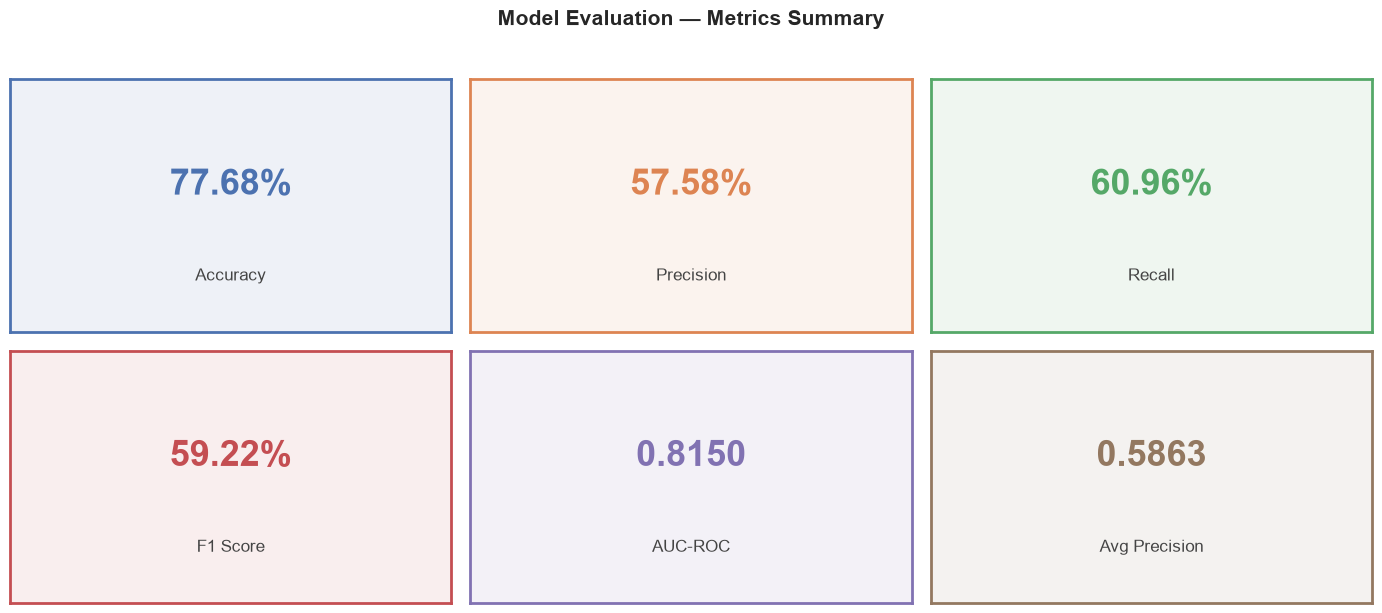

✅ Saved: C:\Users\abhis\Desktop\customer-churn-prediction\images\01_metrics_summary.png


In [16]:
# ─── Visual KPI cards — same layout you'll recreate in Power BI ───────────────

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle(
    "Model Evaluation — Metrics Summary",
    fontsize=15, fontweight="bold", y=1.02
)

card_data = [
    ("Accuracy",       f"{metrics['Accuracy']:.2f}%",      "#4C72B0"),
    ("Precision",      f"{metrics['Precision']:.2f}%",     "#DD8452"),
    ("Recall",         f"{metrics['Recall']:.2f}%",        "#55A868"),
    ("F1 Score",       f"{metrics['F1 Score']:.2f}%",      "#C44E52"),
    ("AUC-ROC",        f"{metrics['AUC-ROC']:.4f}",        "#8172B2"),
    ("Avg Precision",  f"{metrics['Avg Precision']:.4f}",  "#937860"),
]

for ax, (label, value, color) in zip(axes.flat, card_data):
    ax.set_facecolor(color + "18")
    ax.text(0.5, 0.58, value,
            ha="center", va="center",
            fontsize=26, fontweight="bold", color=color,
            transform=ax.transAxes)
    ax.text(0.5, 0.22, label,
            ha="center", va="center",
            fontsize=12, color="#444",
            transform=ax.transAxes)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
out = os.path.join(PATHS["images"], "01_metrics_summary.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {out}")

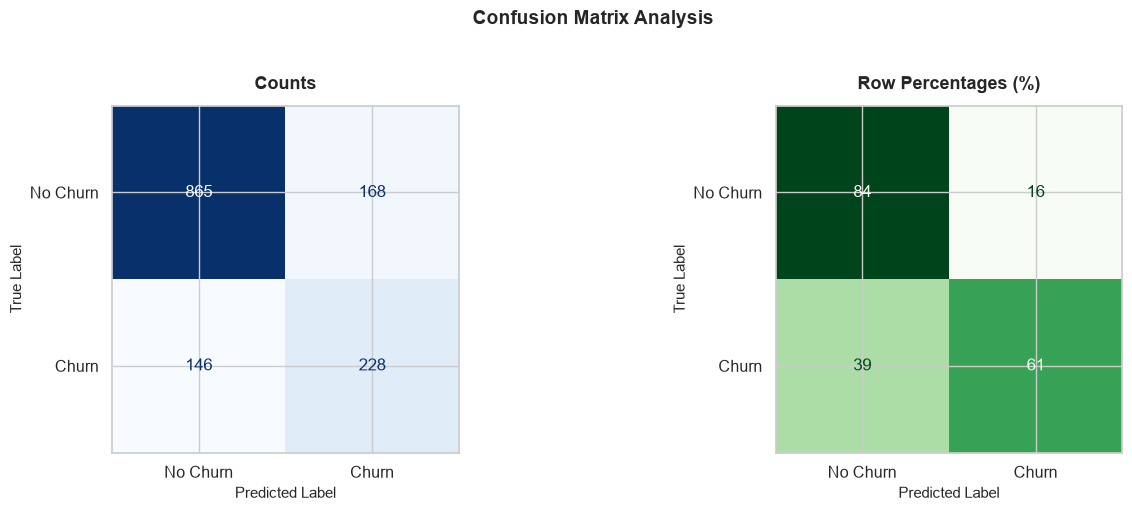

── Confusion Matrix Breakdown ───────────────────────────────
  True Positives  (caught churners)        : 228
  True Negatives  (correct non-churn)      : 865
  False Positives (wasted retention offer) : 168
  False Negatives (missed churners ❌)      : 146

  Churner catch rate (Recall)  : 61.0%
  Missed churner rate          : 39.0%
✅ Saved: C:\Users\abhis\Desktop\customer-churn-prediction\images\02_confusion_matrix.png


In [17]:
# ─── Confusion matrix: counts + row percentages side by side ─────────────────
#
#  TN (top-left)  → Correctly predicted No Churn
#  FP (top-right) → Predicted Churn but actually No Churn (wasted retention $)
#  FN (bot-left)  → Predicted No Churn but actually Churn (missed churner ❌)
#  TP (bot-right) → Correctly predicted Churn  ✅

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrix Analysis", fontsize=14,
             fontweight="bold", y=1.02)

# Left — raw counts
disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)
disp1.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Counts", fontsize=13, fontweight="bold", pad=12)
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("True Label",      fontsize=11)

# Right — row percentages
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_pct.round(1),
    display_labels=["No Churn", "Churn"]
)
disp2.plot(ax=axes[1], colorbar=False, cmap="Greens")
axes[1].set_title("Row Percentages (%)", fontsize=13,
                  fontweight="bold", pad=12)
axes[1].set_xlabel("Predicted Label", fontsize=11)
axes[1].set_ylabel("True Label",      fontsize=11)

plt.tight_layout()
out = os.path.join(PATHS["images"], "02_confusion_matrix.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print("── Confusion Matrix Breakdown ───────────────────────────────")
print(f"  True Positives  (caught churners)        : {tp:,}")
print(f"  True Negatives  (correct non-churn)      : {tn:,}")
print(f"  False Positives (wasted retention offer) : {fp:,}")
print(f"  False Negatives (missed churners ❌)      : {fn:,}")
print(f"\n  Churner catch rate (Recall)  : {tp/(tp+fn)*100:.1f}%")
print(f"  Missed churner rate          : {fn/(tp+fn)*100:.1f}%")
print(f"✅ Saved: {out}")

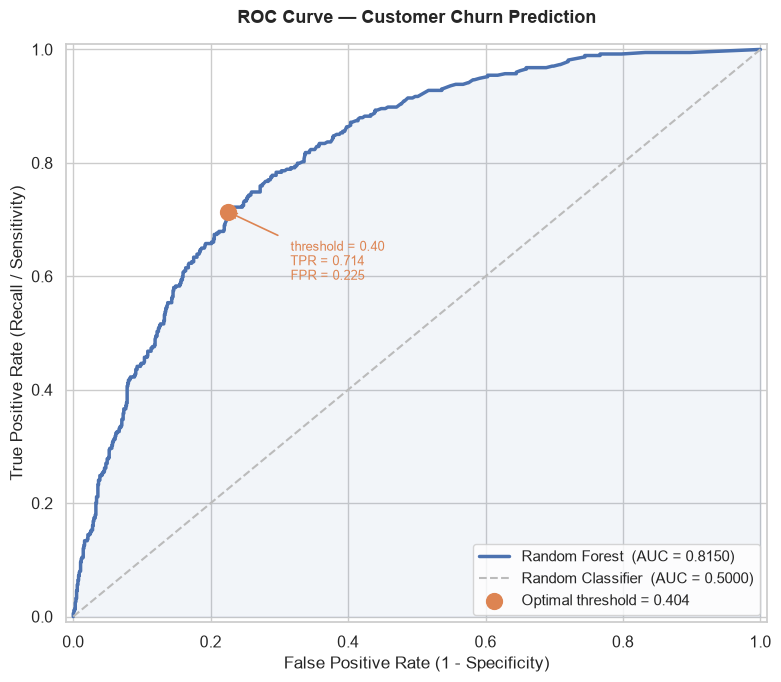

AUC-ROC                       : 0.8150
Optimal threshold (Youden's J): 0.4042
  TPR at optimal threshold    : 0.7139
  FPR at optimal threshold    : 0.2246
✅ Saved: C:\Users\abhis\Desktop\customer-churn-prediction\images\03_roc_curve.png


In [18]:
# ─── ROC Curve ────────────────────────────────────────────────────────────────
#
#  X-axis → False Positive Rate  (wasted offers)
#  Y-axis → True Positive Rate   (caught churners)
#
#  AUC = 1.0  → Perfect model
#  AUC = 0.5  → Random coin flip (diagonal dashed line)
#
#  Youden's J statistic finds the optimal threshold:
#  J = TPR − FPR   (maximised at the best operating point)

fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

# Optimal threshold via Youden's J
j_scores      = tpr - fpr
opt_idx       = np.argmax(j_scores)
opt_threshold = thresholds_roc[opt_idx]
opt_fpr       = fpr[opt_idx]
opt_tpr       = tpr[opt_idx]

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(fpr, tpr,
        color="#4C72B0", lw=2.5,
        label=f"Random Forest  (AUC = {roc_auc_val:.4f})")

ax.plot([0, 1], [0, 1],
        color="#bbb", lw=1.5, linestyle="--",
        label="Random Classifier  (AUC = 0.5000)")

ax.scatter(opt_fpr, opt_tpr,
           color="#DD8452", s=130, zorder=5,
           label=f"Optimal threshold = {opt_threshold:.3f}")

ax.annotate(
    f"  threshold = {opt_threshold:.2f}\n"
    f"  TPR = {opt_tpr:.3f}\n"
    f"  FPR = {opt_fpr:.3f}",
    xy=(opt_fpr, opt_tpr),
    xytext=(opt_fpr + 0.08, opt_tpr - 0.12),
    fontsize=9, color="#DD8452",
    arrowprops=dict(arrowstyle="->", color="#DD8452", lw=1.2)
)

ax.fill_between(fpr, tpr, alpha=0.07, color="#4C72B0")
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall / Sensitivity)", fontsize=12)
ax.set_title("ROC Curve — Customer Churn Prediction",
             fontsize=13, fontweight="bold", pad=15)
ax.legend(fontsize=11, loc="lower right")
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
out = os.path.join(PATHS["images"], "03_roc_curve.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"AUC-ROC                       : {roc_auc_val:.4f}")
print(f"Optimal threshold (Youden's J): {opt_threshold:.4f}")
print(f"  TPR at optimal threshold    : {opt_tpr:.4f}")
print(f"  FPR at optimal threshold    : {opt_fpr:.4f}")
print(f"✅ Saved: {out}")

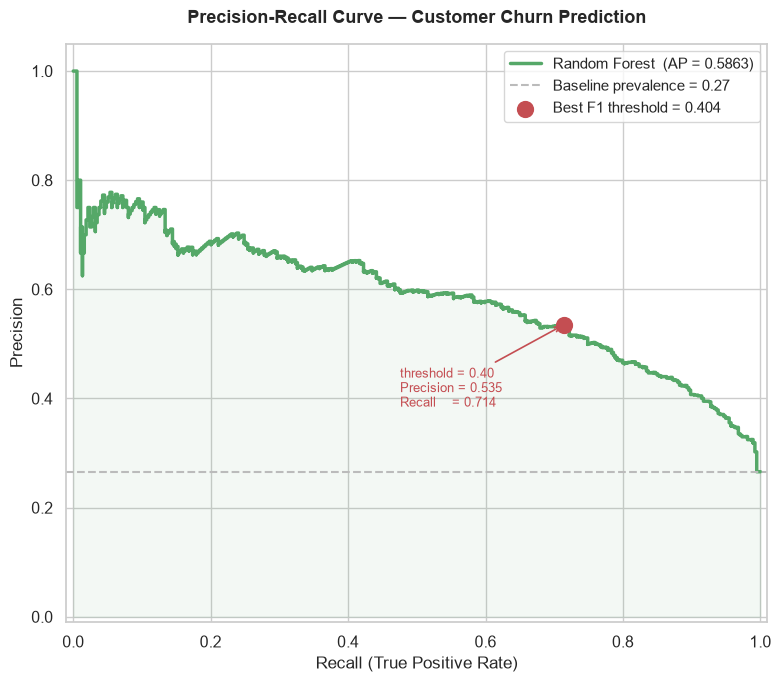

Average Precision (AP)      : 0.5863
Best F1 on PR curve         : 0.6117
Threshold for best PR F1    : 0.4042
  Precision at that point   : 0.5351
  Recall    at that point   : 0.7139
✅ Saved: C:\Users\abhis\Desktop\customer-churn-prediction\images\04_precision_recall_curve.png


In [19]:
# ─── Precision-Recall Curve ───────────────────────────────────────────────────
#
#  WHY use PR curve alongside ROC?
#  With 27% positive class, ROC can look overly optimistic because it
#  accounts for True Negatives (abundant and easy to get right).
#  PR curve focuses ONLY on the positive class (churners) — more honest.
#
#  Average Precision (AP) = area under the PR curve
#  Baseline = the positive class prevalence (~0.27)

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(
    y_test, y_prob
)
ap_score     = average_precision_score(y_test, y_prob)
baseline_pr  = y_test.mean()

# Best F1 point on the PR curve
f1_pr = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) == 0, 0,
    2 * precision_vals[:-1] * recall_vals[:-1]
    / (precision_vals[:-1] + recall_vals[:-1])
)
best_pr_idx    = np.argmax(f1_pr)
best_pr_thresh = thresholds_pr[best_pr_idx]
best_pr_prec   = precision_vals[best_pr_idx]
best_pr_rec    = recall_vals[best_pr_idx]

fig, ax = plt.subplots(figsize=(8, 7))

ax.step(recall_vals, precision_vals,
        where="post", color="#55A868", lw=2.5,
        label=f"Random Forest  (AP = {ap_score:.4f})")

ax.axhline(baseline_pr,
           color="#bbb", lw=1.5, linestyle="--",
           label=f"Baseline prevalence = {baseline_pr:.2f}")

ax.scatter(best_pr_rec, best_pr_prec,
           color="#C44E52", s=130, zorder=5,
           label=f"Best F1 threshold = {best_pr_thresh:.3f}")

ax.annotate(
    f"  threshold = {best_pr_thresh:.2f}\n"
    f"  Precision = {best_pr_prec:.3f}\n"
    f"  Recall    = {best_pr_rec:.3f}",
    xy=(best_pr_rec, best_pr_prec),
    xytext=(best_pr_rec - 0.25, best_pr_prec - 0.15),
    fontsize=9, color="#C44E52",
    arrowprops=dict(arrowstyle="->", color="#C44E52", lw=1.2)
)

ax.fill_between(recall_vals, precision_vals,
                alpha=0.07, color="#55A868", step="post")

ax.set_xlabel("Recall (True Positive Rate)", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve — Customer Churn Prediction",
             fontsize=13, fontweight="bold", pad=15)
ax.legend(fontsize=11, loc="upper right")
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])

plt.tight_layout()
out = os.path.join(PATHS["images"], "04_precision_recall_curve.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Average Precision (AP)      : {ap_score:.4f}")
print(f"Best F1 on PR curve         : {f1_pr[best_pr_idx]:.4f}")
print(f"Threshold for best PR F1    : {best_pr_thresh:.4f}")
print(f"  Precision at that point   : {best_pr_prec:.4f}")
print(f"  Recall    at that point   : {best_pr_rec:.4f}")
print(f"✅ Saved: {out}")

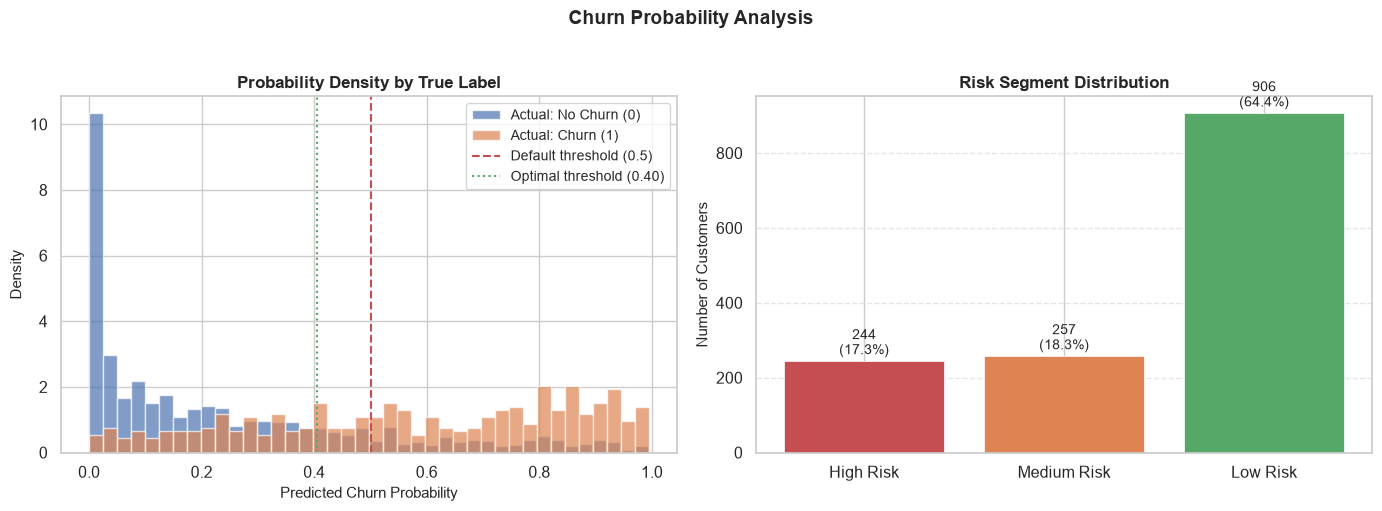

✅ Saved: C:\Users\abhis\Desktop\customer-churn-prediction\images\05_probability_distribution.png


In [20]:
# ─── Probability distribution plots ──────────────────────────────────────────
#
#  A well-calibrated model shows BIMODAL distribution:
#  → Mass near 0.0  (confident No Churn predictions)
#  → Mass near 1.0  (confident Churn predictions)
#  → Minimal mass in middle (fewer uncertain predictions)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Churn Probability Analysis",
             fontsize=14, fontweight="bold", y=1.02)

# ── Left: distribution by actual label ────────────────────────────────────────
axes[0].hist(
    y_prob[y_test == 0], bins=40,
    alpha=0.70, color="#4C72B0",
    label="Actual: No Churn (0)", density=True
)
axes[0].hist(
    y_prob[y_test == 1], bins=40,
    alpha=0.70, color="#DD8452",
    label="Actual: Churn (1)", density=True
)
axes[0].axvline(
    0.5, color="#C44E52", lw=1.5,
    linestyle="--", label="Default threshold (0.5)"
)
axes[0].axvline(
    opt_threshold, color="#55A868", lw=1.5,
    linestyle=":", label=f"Optimal threshold ({opt_threshold:.2f})"
)
axes[0].set_xlabel("Predicted Churn Probability", fontsize=11)
axes[0].set_ylabel("Density", fontsize=11)
axes[0].set_title("Probability Density by True Label",
                  fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)

# ── Right: risk segment bar chart ─────────────────────────────────────────────
seg_order  = ["High Risk", "Medium Risk", "Low Risk"]
seg_counts = [( risk_labels == s).sum() for s in seg_order]
seg_colors = ["#C44E52", "#DD8452", "#55A868"]

bars = axes[1].bar(
    seg_order, seg_counts,
    color=seg_colors, edgecolor="white", linewidth=0.5
)
for bar, count in zip(bars, seg_counts):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        f"{count:,}\n({count/len(risk_labels)*100:.1f}%)",
        ha="center", va="bottom", fontsize=10
    )

axes[1].set_ylabel("Number of Customers", fontsize=11)
axes[1].set_title("Risk Segment Distribution",
                  fontsize=12, fontweight="bold")
axes[1].yaxis.grid(True, linestyle="--", alpha=0.5)
axes[1].set_axisbelow(True)

plt.tight_layout()
out = os.path.join(PATHS["images"], "05_probability_distribution.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {out}")

Top 15 Features:
                       Feature  Importance
                        tenure    0.118571
                  TotalCharges    0.111479
                MonthlyCharges    0.103327
       Contract_Month-to-month    0.100928
                TechSupport_No    0.050049
             OnlineSecurity_No    0.043624
PaymentMethod_Electronic check    0.035925
             Contract_Two year    0.034462
              PaperlessBilling    0.032079
   InternetService_Fiber optic    0.029418
                        gender    0.028611
                       Partner    0.027490
                    Dependents    0.022589
             Contract_One year    0.020237
               OnlineBackup_No    0.017591


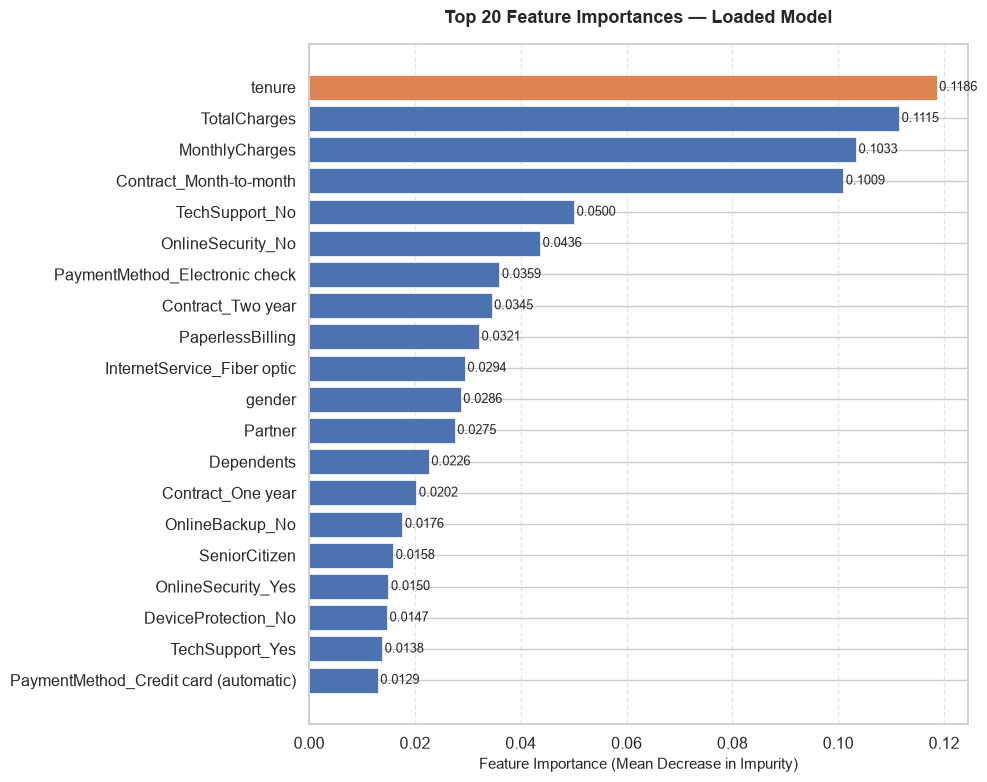

✅ Saved: C:\Users\abhis\Desktop\customer-churn-prediction\images\06_feature_importance.png


In [21]:
# ─── Feature importance from loaded model ─────────────────────────────────────
# We re-plot here to confirm the .pkl file loads correctly and
# produces the same importances as during training.

importance_df = pd.DataFrame({
    "Feature"   : feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top 15 Features:")
print(importance_df.head(15).to_string(index=False))

TOP_N     = 20
plot_data = importance_df.head(TOP_N).iloc[::-1]

bar_colors = [
    "#DD8452" if i == len(plot_data) - 1 else "#4C72B0"
    for i in range(len(plot_data))
]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    plot_data["Feature"],
    plot_data["Importance"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.0005,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.4f}",
        va="center", ha="left", fontsize=9
    )

ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)", fontsize=11)
ax.set_title(f"Top {TOP_N} Feature Importances — Loaded Model",
             fontsize=13, fontweight="bold", pad=15)
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
out = os.path.join(PATHS["images"], "06_feature_importance.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {out}")

In [22]:
# ─── Build model_predictions.csv ──────────────────────────────────────────────
#
#  This file is what the Power BI dashboard imports.
#  We join model outputs back to ORIGINAL (unscaled) cleaned columns
#  so dashboard slicers show real values like "Month-to-month", "72", "$89.10"
#  instead of scaled floats like "0.341", "-1.22".
#
#  Strategy: Re-create the same train/test split using identical
#             random_state=42 and stratify=Churn to recover test row indices.
#             We are NOT refitting any model — only recovering which rows
#             went into the test set.

_, test_subset = train_test_split(
    cleaned_df,
    test_size    = len(y_test) / len(cleaned_df),
    random_state = SEED,
    stratify     = cleaned_df["Churn"]
)
test_subset = test_subset.reset_index(drop=True)

# ─── Attach model outputs ─────────────────────────────────────────────────────
predictions_df = test_subset.copy()
predictions_df["Predicted_Churn"]     = y_pred
predictions_df["Churn_Probability"]   = y_prob.round(4)
predictions_df["Risk_Segment"]        = risk_labels
predictions_df["Prediction_Correct"]  = (y_pred == y_test).astype(int)
predictions_df["Actual_Label"]        = np.where(y_test  == 1, "Churn", "No Churn")
predictions_df["Predicted_Label"]     = np.where(y_pred  == 1, "Churn", "No Churn")

# ─── Save ─────────────────────────────────────────────────────────────────────
predictions_df.to_csv(PATHS["predictions"], index=False)

print(f"✅ Saved: {PATHS['predictions']}")
print(f"   Rows    : {len(predictions_df):,}")
print(f"   Columns : {predictions_df.shape[1]}")
print(f"\nColumn list:")
for col in predictions_df.columns:
    print(f"  {col}")

# ─── Preview ──────────────────────────────────────────────────────────────────
preview_cols = [
    c for c in
    ["tenure", "Contract", "MonthlyCharges", "TotalCharges",
     "Actual_Label", "Predicted_Label",
     "Churn_Probability", "Risk_Segment", "Prediction_Correct"]
    if c in predictions_df.columns
]

print(f"\n── Preview (5 rows) ──────────────────────────────────────────")
print(predictions_df[preview_cols].head().to_string(index=False))

✅ Saved: C:\Users\abhis\Desktop\customer-churn-prediction\data\processed\model_predictions.csv
   Rows    : 1,407
   Columns : 47

Column list:
  gender
  SeniorCitizen
  Partner
  Dependents
  tenure
  PhoneService
  PaperlessBilling
  MonthlyCharges
  TotalCharges
  Churn
  MultipleLines_No
  MultipleLines_No phone service
  MultipleLines_Yes
  InternetService_DSL
  InternetService_Fiber optic
  InternetService_No
  OnlineSecurity_No
  OnlineSecurity_No internet service
  OnlineSecurity_Yes
  OnlineBackup_No
  OnlineBackup_No internet service
  OnlineBackup_Yes
  DeviceProtection_No
  DeviceProtection_No internet service
  DeviceProtection_Yes
  TechSupport_No
  TechSupport_No internet service
  TechSupport_Yes
  StreamingTV_No
  StreamingTV_No internet service
  StreamingTV_Yes
  StreamingMovies_No
  StreamingMovies_No internet service
  StreamingMovies_Yes
  Contract_Month-to-month
  Contract_One year
  Contract_Two year
  PaymentMethod_Bank transfer (automatic)
  PaymentMethod_Cre

In [23]:
print("═" * 62)
print("   CUSTOMER CHURN PREDICTION — EVALUATION COMPLETE")
print("═" * 62)
print(f"   Model          : {type(model).__name__} (tuned)")
print(f"   Test samples   : {len(y_test):,}")
print()
print("   ── PERFORMANCE METRICS ──────────────────────────────")
print(f"   {'Accuracy':<22}: {metrics['Accuracy']:.2f}%")
print(f"   {'Precision':<22}: {metrics['Precision']:.2f}%")
print(f"   {'Recall':<22}: {metrics['Recall']:.2f}%")
print(f"   {'F1 Score':<22}: {metrics['F1 Score']:.2f}%")
print(f"   {'AUC-ROC':<22}: {metrics['AUC-ROC']:.4f}")
print(f"   {'Avg Precision (AP)':<22}: {metrics['Avg Precision']:.4f}")
print()
print("   ── BUSINESS IMPACT ──────────────────────────────────")
print(f"   High-risk customers flagged  : {(risk_labels=='High Risk').sum():,}")
print(f"   Churners correctly caught    : {tp:,}  (Recall {tp/(tp+fn)*100:.1f}%)")
print(f"   Churners missed              : {fn:,}")
print(f"   Wasted retention offers      : {fp:,}")
print()
print("   ── OUTPUT FILES ──────────────────────────────────────")

saved_imgs = sorted([
    f for f in os.listdir(PATHS["images"])
    if f.endswith(".png")
])
for img in saved_imgs:
    print(f"   ✅  images/{img}")

print(f"   ✅  {PATHS['predictions']}")
print()
print("   ── NEXT STEP ─────────────────────────────────────────")
print("   Open Power BI Desktop")
print("   → Get Data → CSV")
print("   → data/processed/model_predictions.csv")
print("   → Build KPI cards, slicers, and churn risk visuals")
print("═" * 62)

══════════════════════════════════════════════════════════════
   CUSTOMER CHURN PREDICTION — EVALUATION COMPLETE
══════════════════════════════════════════════════════════════
   Model          : RandomForestClassifier (tuned)
   Test samples   : 1,407

   ── PERFORMANCE METRICS ──────────────────────────────
   Accuracy              : 77.68%
   Precision             : 57.58%
   Recall                : 60.96%
   F1 Score              : 59.22%
   AUC-ROC               : 0.8150
   Avg Precision (AP)    : 0.5863

   ── BUSINESS IMPACT ──────────────────────────────────
   High-risk customers flagged  : 244
   Churners correctly caught    : 228  (Recall 61.0%)
   Churners missed              : 146
   Wasted retention offers      : 168

   ── OUTPUT FILES ──────────────────────────────────────
   ✅  images/01_metrics_summary.png
   ✅  images/02_confusion_matrix.png
   ✅  images/03_roc_curve.png
   ✅  images/04_precision_recall_curve.png
   ✅  images/05_probability_distribution.png
   ✅  im